# SMAP Pixel Land-Use Composition
This notebook computes land-use classes inside a SMAP pixel and reports area percentage by class.

In [1]:
# Install if needed: pip install geopandas pandas matplotlib pyproj
from pathlib import Path
import warnings

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)

In [2]:
# Update these paths to your files
smap_pixel_shape = Path(r"C:\SoilGrids\zhurucay\SMAP_pixel_zhurucay.shp")
landuse_path = Path(r"C:\SoilGrids\cobertura_vegetal\Cobertura_vegetal_ECUADOR_2022_100k_UTM_WGS84_17S.shp")

# Optional: where to save output CSV
output_csv = Path(r"c:\Bachelorarbeit\resultados\smap_pixel_landuse_percentages.csv")

print('SMAP pixel:', smap_pixel_shape)
print('Land use :', landuse_path)
print('CSV out  :', output_csv)

SMAP pixel: C:\SoilGrids\zhurucay\SMAP_pixel_zhurucay.shp
Land use : C:\SoilGrids\cobertura_vegetal\Cobertura_vegetal_ECUADOR_2022_100k_UTM_WGS84_17S.shp
CSV out  : c:\Bachelorarbeit\resultados\smap_pixel_landuse_percentages.csv


In [3]:
# Read shapefiles
smap = gpd.read_file(smap_pixel_shape)
landuse = gpd.read_file(landuse_path)

print('SMAP features   :', len(smap))
print('Land-use features:', len(landuse))
print('SMAP CRS   :', smap.crs)
print('Land-use CRS:', landuse.crs)

SMAP features   : 1
Land-use features: 279077
SMAP CRS   : EPSG:4326
Land-use CRS: EPSG:32717


In [4]:
# Choose a projected CRS to compute area in square meters
# Prefer UTM 17S (EPSG:32717) given your data description.
target_crs = 'EPSG:32717'

if smap.crs is None or landuse.crs is None:
    raise ValueError('One or both layers have no CRS defined. Define CRS before analysis.')

smap_proj = smap.to_crs(target_crs)
landuse_proj = landuse.to_crs(target_crs)

# Dissolve SMAP to a single polygon in case it contains multiple parts
smap_union = smap_proj.dissolve()
smap_union = smap_union[['geometry']].copy()

# Clip land use to SMAP extent for performance
landuse_clip = gpd.clip(landuse_proj, smap_union)

print('Land-use features intersecting SMAP:', len(landuse_clip))

Land-use features intersecting SMAP: 21


In [10]:
# Identify land-use attribute column
print('Land-use columns:')
print(list(landuse_clip.columns))

# Use the confirmed land-use class field
landuse_col = 'ctn2'
if landuse_col not in landuse_clip.columns:
    raise ValueError(f"Expected land-use column '{landuse_col}' not found. Available: {list(landuse_clip.columns)}")

print('Using land-use category column:', landuse_col)

Land-use columns:
['objectid', 'fcode', 'ctn1', 'ctn2', 'anio', 'are', 'vuln_score', 'geometry']
Using land-use category column: ctn2


In [11]:
# Intersect and calculate area per land-use class
intersections = gpd.overlay(
    landuse_clip[[landuse_col, 'geometry']].copy(),
    smap_union[['geometry']].copy(),
    how='intersection'
)

if intersections.empty:
    raise ValueError('No overlap found between SMAP pixel and land-use polygons.')

intersections['area_m2'] = intersections.geometry.area
total_area_m2 = intersections['area_m2'].sum()

summary = (
    intersections.groupby(landuse_col, dropna=False)['area_m2']
    .sum()
    .reset_index()
    .sort_values('area_m2', ascending=False)
)
summary['pct_of_smap'] = 100.0 * summary['area_m2'] / total_area_m2
summary['area_ha'] = summary['area_m2'] / 10000.0

# Reorder columns
summary = summary[[landuse_col, 'area_m2', 'area_ha', 'pct_of_smap']]

# Nice formatting copy for display
summary_display = summary.copy()
summary_display['area_m2'] = summary_display['area_m2'].round(2)
summary_display['area_ha'] = summary_display['area_ha'].round(4)
summary_display['pct_of_smap'] = summary_display['pct_of_smap'].round(2)

print(f'Total intersected area: {total_area_m2:,.2f} m2')
summary_display

Total intersected area: 111,330,021.95 m2


,ctn2,area_m2,area_ha,pct_of_smap
3,PARAMO,1.093899e+08,10938.9872,98.26
4,PASTIZAL,9.054000e+05,90.5400,0.81
1,CUERPO DE AGUA NATURAL,5.240650e+05,52.4065,0.47
5,PLANTACION FORESTAL,2.730854e+05,27.3085,0.25
2,INFRAESTRUCTURA,2.313000e+05,23.1300,0.21
0,BOSQUE NATIVO,6.300000e+03,0.6300,0.01


In [12]:
# Save results
output_csv.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(output_csv, index=False)
print('Saved:', output_csv)

Saved: c:\Bachelorarbeit\resultados\smap_pixel_landuse_percentages.csv


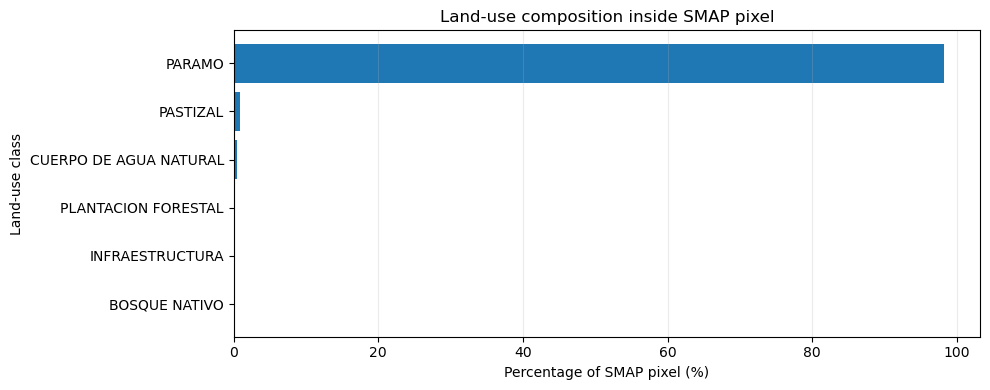

In [13]:
# Plot percentage composition
plot_df = summary_display.sort_values('pct_of_smap', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(plot_df))))
ax.barh(plot_df[landuse_col].astype(str), plot_df['pct_of_smap'])
ax.set_xlabel('Percentage of SMAP pixel (%)')
ax.set_ylabel('Land-use class')
ax.set_title('Land-use composition inside SMAP pixel')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()